# Importation des libraries

In [2]:
import rds2py
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pds
#import libraries
import scanpy as sc
import cell2location as c2l
import squidpy as sq


/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


# Sein : HT425B1

In [3]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

#lire les données 
pan224_sc = sc.read("data/data_h5ad/snRNA_L4__HT425B1-S1H1_combo.h5ad") # mettre le nom du fichier scRNAseq

pan224_st = sc.read("data/data_h5ad/HT425B1-S1H2Fs1U1Bp1-SeuratObj.h5ad") # mettre le nom du fichier spatial
pan224_st.obsm['spatial'] = pan224_st.obsm["X_spatial"]
#Traitement de données spatial
sc.pp.normalize_total(pan224_st)
sc.pp.log1p(pan224_st)
sc.pp.pca(pan224_st,n_comps=10)
sc.pp.neighbors(pan224_st)
sc.tl.leiden(pan224_st)
sc.tl.umap(pan224_st)

print(pan224_sc)
print(pan224_st)

KeyError: 'X_spatial'

In [4]:
pan224_st

AnnData object with n_obs × n_vars = 2295 × 36601
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent_mt', 'percent_rb', 'percent_hb', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'Tumor_purity_estimate'
    var: 'features'
    obsm: 'X_umap'

In [ ]:
sq.pl.spatial_scatter(pan224_st, shape=None, color="leiden", size=10)

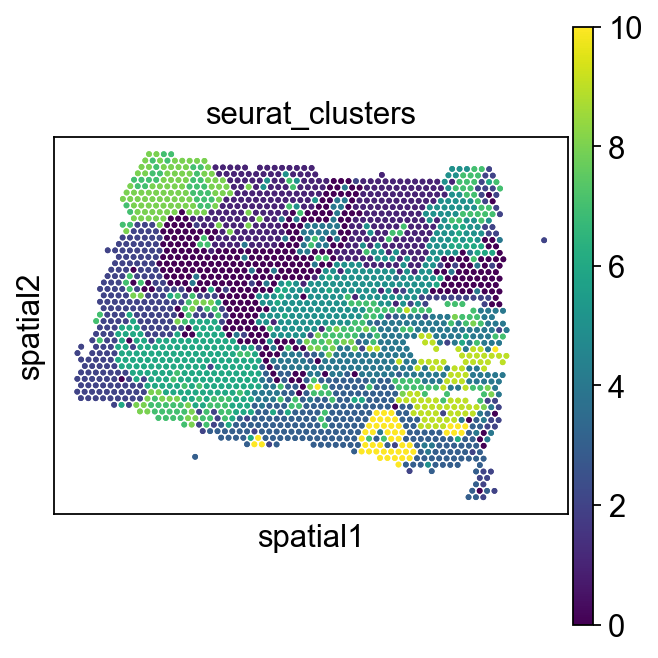

In [79]:
sq.pl.spatial_scatter(pan224_st, shape=None, color="seurat_clusters", size=10)

Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)


/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


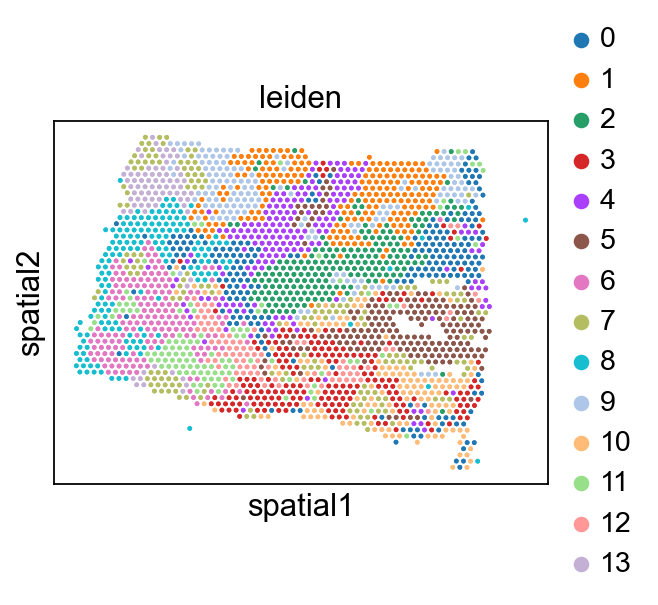

In [80]:
sq.gr.spatial_neighbors(pan224_st, radius=3.0)
sq.pl.spatial_scatter(
    pan224_st,
    color="leiden",
    connectivity_key="spatial_connectivities",
    edges_color="black",
    shape=None,
    edges_width=1,
    size=5,
)

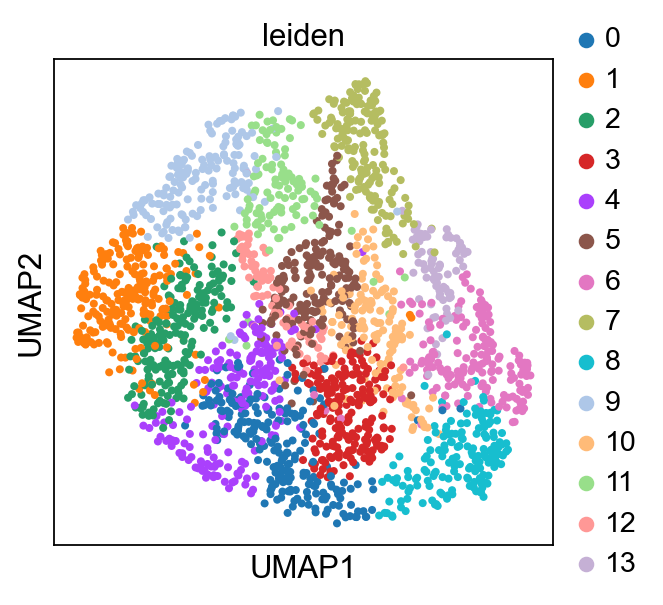

In [82]:
sc.pl.umap(pan224_st, color = "leiden")

Mitochondia-encoded genes (gene names start with prefix mt- or MT-) are irrelevant for spatial mapping because their expression represents technical artifacts in the single cell and nucleus data rather than biological abundance of mitochondria. Yet these genes compose 15-40% of mRNA in each location. Hence, to avoid mapping artifacts we strongly recommend removing mitochondrial genes.

In [86]:
#gènes mitochondriaux
# find mitochondrial (MT) genes
pan224_st.var["MT_gene"] = [
    gene.startswith("MT-") for gene in pan224_st.var["features"]
]

# remove MT genes for spatial mapping (keeping their counts in the object)
pan224_st.obsm["MT"] = pan224_st[:, pan224_st.var["MT_gene"].values].X.toarray()
pan224_st = pan224_st[:, ~pan224_st.var["MT_gene"].values]

In [87]:
shared_features = [
    feature for feature in pan224_st.var_names if feature in pan224_sc.var_names
]
adata_sc = pan224_sc[:, shared_features].copy()
adata_st = pan224_st[:, shared_features].copy()

In [ ]:
#configurer et entrainer sur scRNAseq
c2l.models.RegressionModel.setup_anndata(
    adata=adata_sc,
    labels_key="cell_type"
)

model = c2l.models.RegressionModel(adata_sc)

model.train(max_epochs=500, batch_size=2500, train_size=1, lr=0.002)




/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 0 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.p

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [44]:
model.save("models/ht224p1_sc_regression", overwrite=True)

In [ ]:
#Pour charger model
loaded_model = c2l.models.RegressionModel.load(
    "models/sc_regression",
    adata=adata_sc
)

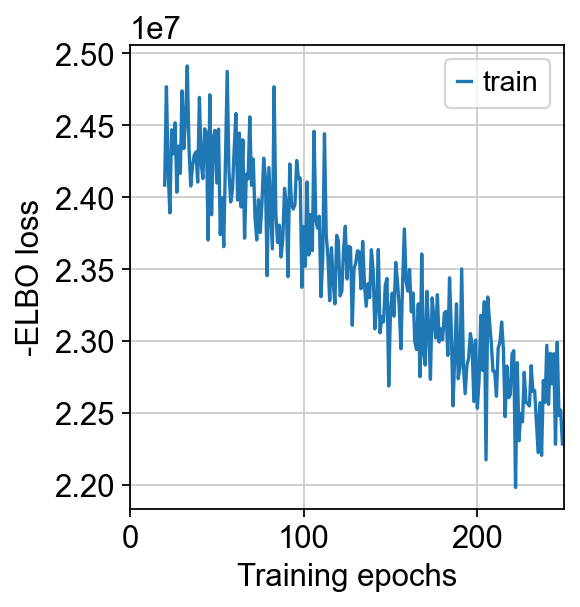

In [43]:
model.plot_history(20)


In [45]:
# Exporter signatures
model.export_posterior(
    adata_sc,
    sample_kwargs={"num_samples": 1000, "batch_size": 2500,},
)

inf_aver = adata_sc.varm['means_per_cluster_mu_fg']  # genes x cell_types
inf_aver.to_csv('signatures.csv')  # réutilisable

/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/model/base/_pyromixin.py:499: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


Sampling local variables, batch:   0%|          | 0/2 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

In [51]:
# gènes partagés entre spatial et signatures
common_genes = adata_st.var_names.intersection(inf_aver.index)

# filtrer les signatures
inf_aver_filtered = inf_aver.loc[common_genes]
inf_aver_filtered

,means_per_cluster_mu_fg_ADM,means_per_cluster_mu_fg_B-cells,means_per_cluster_mu_fg_Ductal-like1,means_per_cluster_mu_fg_Ductal-like2,means_per_cluster_mu_fg_Endothelial,means_per_cluster_mu_fg_Fibroblasts,means_per_cluster_mu_fg_Islets,means_per_cluster_mu_fg_Low quality,means_per_cluster_mu_fg_Macrophages,means_per_cluster_mu_fg_Mast,means_per_cluster_mu_fg_Other_doublets,means_per_cluster_mu_fg_Plasma,means_per_cluster_mu_fg_T-cells,means_per_cluster_mu_fg_Tumor
LINC02593,0.000280,0.000280,0.000282,0.000279,0.000277,0.051590,0.000278,0.000282,0.000276,0.000280,0.000277,0.000280,0.000274,0.002531
SAMD11,0.000283,0.000276,0.000281,0.035691,0.000282,0.254494,0.079904,0.000279,0.006165,0.000282,0.000281,0.040850,0.001535,0.006737
HES4,0.000281,0.000278,0.168541,0.120724,0.000278,0.190364,0.000280,0.041749,0.004674,0.054651,0.000276,0.000276,0.002529,0.065981
ISG15,0.000278,0.000278,0.000282,0.000280,0.000280,0.025763,0.000279,0.000278,0.018051,0.000284,0.000279,0.008210,0.013402,0.026050
AGRN,0.000276,0.000281,0.168852,0.146429,0.285869,0.026629,0.046268,0.074795,0.023534,0.000276,0.457306,0.000275,0.004045,0.335933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,1.522455,0.305466,0.000284,0.113904,0.849740,0.250512,0.216728,0.428559,0.420509,0.054043,0.456095,0.184308,0.306721,0.257386
MT-ND4,2.867318,0.907532,0.296918,0.805017,1.996011,1.265062,0.726667,1.170716,2.147895,1.088763,1.822206,0.828420,1.756903,1.533334
MT-ND5,1.950918,0.198537,0.173038,0.195726,0.467773,0.501915,0.368163,0.576121,0.797979,0.292033,0.730018,0.372299,0.724488,0.666736
MT-CYB,1.969694,0.287667,0.626801,0.545035,2.834222,1.223802,1.130833,1.717335,1.843950,0.933836,3.066264,0.798210,2.212728,1.887671


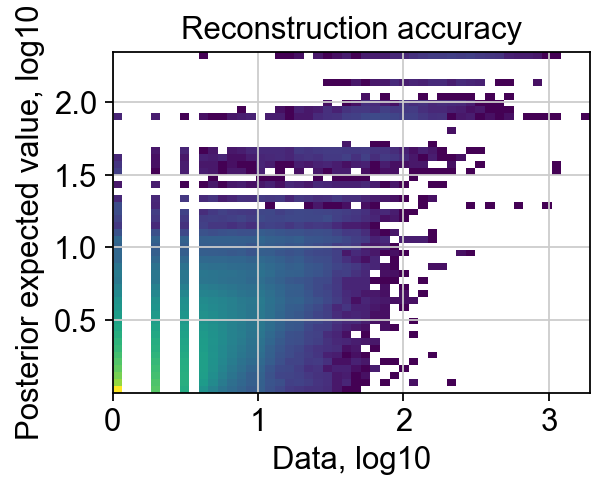

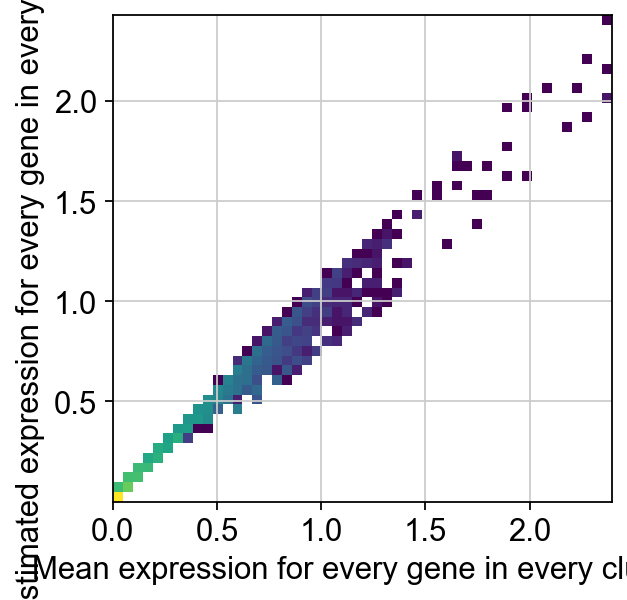

In [46]:
model.plot_QC()  # diagonal reconstruction

In [79]:
adata_st.brut

AnnData object with n_obs × n_vars = 2295 × 3000
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent_mt', 'percent_rb', 'percent_hb', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'Tumor_purity_estimate'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

In [89]:
adata_st.obs = adata_st.obs[["nCount_Spatial","nFeature_Spatial"]]

In [99]:
print(adata_st.obs)

                    orig.ident  nCount_Spatial  nFeature_Spatial  percent_mt  \
AAACAAGTATCTCCCA-1           0         18947.0              5483    2.332823   
AAACAGCTTTCAGAAG-1           0          3800.0              1977    3.342105   
AAACAGGGTCTATATT-1           0          3608.0              1855    1.607539   
AAACATTTCCCGGATT-1           0         10921.0              3769    2.060251   
AAACCCGAACGAAATC-1           0         25822.0              6238    2.567578   
...                        ...             ...               ...         ...   
TTGTTAGCAAATTCGA-1           0         16947.0              5365    2.914970   
TTGTTCAGTGTGCTAC-1           0         11209.0              3746    1.980551   
TTGTTGTGTGTCAAGA-1           0         20452.0              5423    2.332290   
TTGTTTCACATCCAGG-1           0          3252.0              1754    1.568266   
TTGTTTCCATACAACT-1           0          3168.0              1744    1.546717   

                    percent_rb  percent

In [101]:
print(adata_st.X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8122762 stored elements and shape (2295, 36601)>
  Coords	Values
  (0, 25)	1.0
  (0, 30)	2.0
  (0, 36)	1.0
  (0, 43)	1.0
  (0, 44)	3.0
  (0, 45)	1.0
  (0, 48)	1.0
  (0, 52)	1.0
  (0, 58)	1.0
  (0, 59)	1.0
  (0, 60)	4.0
  (0, 62)	4.0
  (0, 64)	2.0
  (0, 68)	1.0
  (0, 70)	1.0
  (0, 71)	1.0
  (0, 73)	6.0
  (0, 80)	1.0
  (0, 83)	1.0
  (0, 85)	1.0
  (0, 86)	3.0
  (0, 104)	4.0
  (0, 112)	1.0
  (0, 113)	5.0
  (0, 115)	1.0
  :	:
  (2294, 36097)	3.0
  (2294, 36099)	1.0
  (2294, 36205)	1.0
  (2294, 36237)	2.0
  (2294, 36298)	2.0
  (2294, 36350)	1.0
  (2294, 36366)	4.0
  (2294, 36372)	1.0
  (2294, 36378)	1.0
  (2294, 36380)	1.0
  (2294, 36383)	1.0
  (2294, 36386)	1.0
  (2294, 36390)	1.0
  (2294, 36398)	3.0
  (2294, 36401)	18.0
  (2294, 36415)	1.0
  (2294, 36559)	2.0
  (2294, 36560)	3.0
  (2294, 36561)	9.0
  (2294, 36562)	11.0
  (2294, 36564)	4.0
  (2294, 36565)	5.0
  (2294, 36566)	1.0
  (2294, 36568)	9.0
  (2294, 36571)	5.0


In [102]:
#modele spatial (deconvolution)
c2l.models.Cell2location.setup_anndata(adata_st)
mod_sp = c2l.models.Cell2location(adata_st, cell_state_df=inf_aver,
                                  N_cells_per_location=8)  # ~8 cellules/spot

mod_sp.train(max_epochs=800)  # plus long, GPU recommandé
mod_sp.plot_history()  # convergence
mod_sp.plot_QC()  # diagonal

# Exporter abondances (q05 = confiance haute)
adata_st = mod_sp.export_posterior(adata_st, 
                                   sample_kwargs={'num_samples':1000})
adata_st.obs[mod_sp.factor_names_] = adata_st.obsm['q05_cell_abundance_w_sf']


/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:631: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, self.device = parse_device_args(
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(a

Training:   0%|          | 0/800 [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
#visualization et validation

sc.pl.spatial(adata_st, color=['T-cells', 'Tumor'], 
              img_key='hires', vmin=0, vmax='p99')
sq.pl.spatial_scatter(adata_st, color='region_cluster')  # après clustering

# Clustering régions tissulaires
sc.pp.neighbors(adata_st, use_rep='q05_cell_abundance_w_sf')
sc.tl.leiden(adata_st)
sc.tl.umap(adata_st)



# Sein : HT425B1